### Data Cleaning

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv("StudentsPerformance.csv")
print(df)
# Check for missing values
print(df.isnull().sum())

     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

In [3]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [4]:
# Standardize categorical values: lowercase + strip spaces
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for col in categorical_cols:
    df[col] = df[col].str.lower().str.strip()

# Verify unique values after cleaning
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['female' 'male']
race/ethnicity: ['group b' 'group c' 'group a' 'group d' 'group e']
parental level of education: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
lunch: ['standard' 'free/reduced']
test preparation course: ['none' 'completed']


Math: 0 - 100
Reading: 17 - 100
Writing: 10 - 100


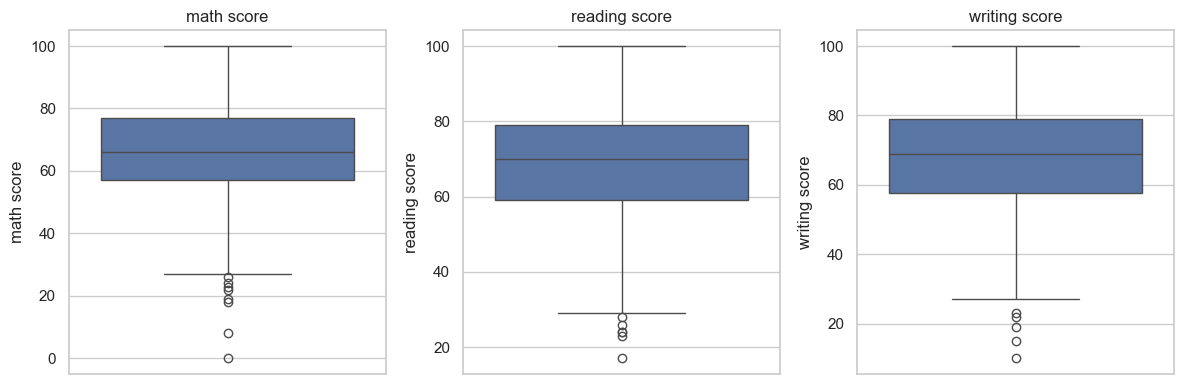

In [5]:
# Check min and max for each score column
print("Math:", df['math score'].min(), "-", df['math score'].max())
print("Reading:", df['reading score'].min(), "-", df['reading score'].max())
print("Writing:", df['writing score'].min(), "-", df['writing score'].max())

# Quick visualization with boxplots
plt.figure(figsize=(12,4))
for i, col in enumerate(['math score','reading score','writing score']):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [6]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=['gender', 'race/ethnicity', 
                                         'parental level of education', 
                                         'lunch', 'test preparation course'],
                            drop_first=True)

# Check the new shape and columns
print(df_encoded.shape)
print(df_encoded.columns)

(1000, 15)
Index(['math score', 'reading score', 'writing score', 'gender_male',
       'race/ethnicity_group b', 'race/ethnicity_group c',
       'race/ethnicity_group d', 'race/ethnicity_group e',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='object')


In [7]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale numeric columns
numeric_cols = ['math score', 'reading score', 'writing score']
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# Verify scaling
print(df_encoded[numeric_cols].head())

   math score  reading score  writing score
0    0.390024       0.193999       0.391492
1    0.192076       1.427476       1.313269
2    1.577711       1.770109       1.642475
3   -1.259543      -0.833899      -1.583744
4    0.653954       0.605158       0.457333


### EDA

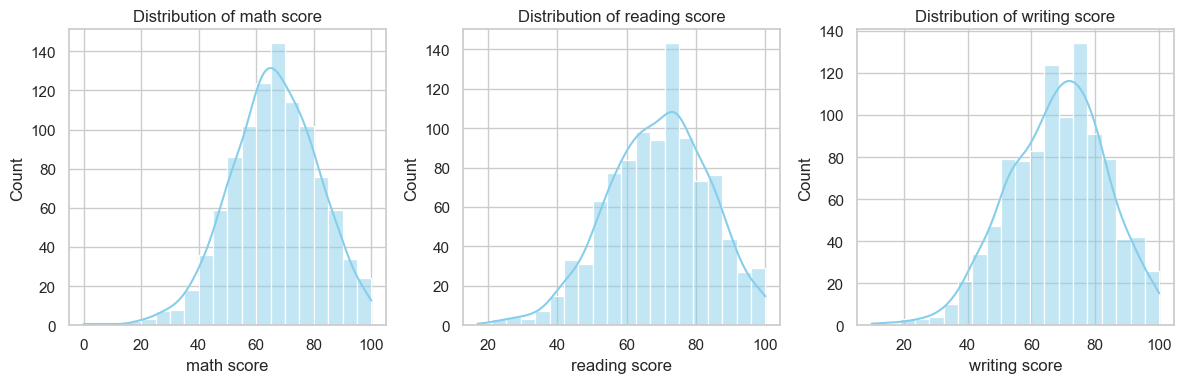

In [8]:
# Distribution plots for scores
plt.figure(figsize=(12,4))

for i, col in enumerate(['math score','reading score','writing score']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

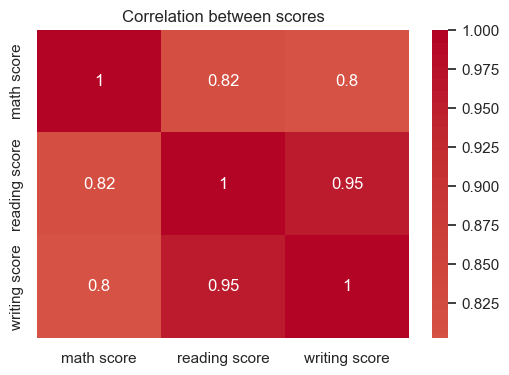

In [9]:
# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score','reading score','writing score']].corr(), 
            annot=True, cmap='coolwarm', center=0)
plt.title("Correlation between scores")
plt.show()

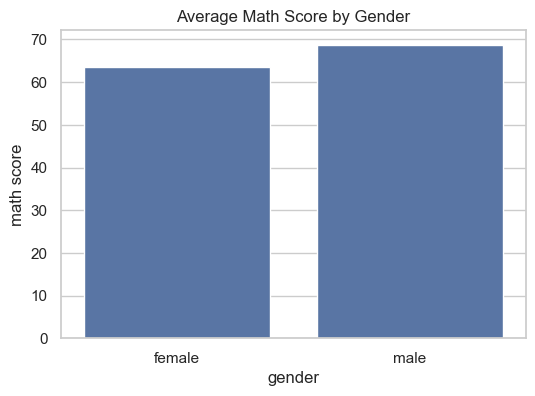

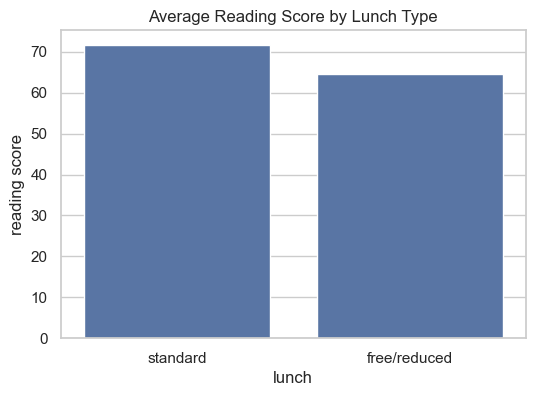

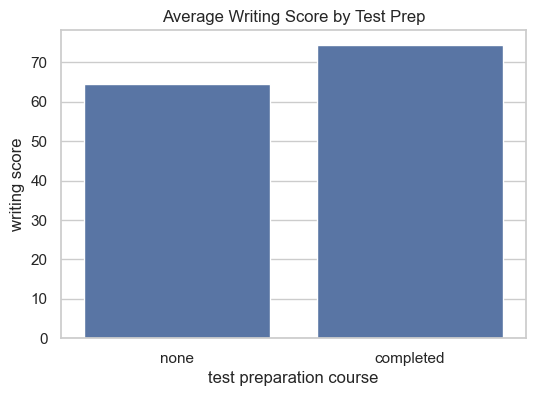

In [10]:
# Average scores by gender
plt.figure(figsize=(6,4))
sns.barplot(x='gender', y='math score', data=df, errorbar=None)
plt.title("Average Math Score by Gender")
plt.show()

# Average scores by lunch type
plt.figure(figsize=(6,4))
sns.barplot(x='lunch', y='reading score', data=df, errorbar=None)
plt.title("Average Reading Score by Lunch Type")
plt.show()

# Average scores by test preparation course
plt.figure(figsize=(6,4))
sns.barplot(x='test preparation course', y='writing score', data=df, errorbar=None)
plt.title("Average Writing Score by Test Prep")
plt.show()

### Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop(['math score','reading score','writing score'], axis=1)
y = df_encoded[['math score','reading score','writing score']]  # predicting scores

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (800, 12) (800, 3)
Test shape: (200, 12) (200, 3)


### Train ML Model

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model
lr = LinearRegression()

# Train on training set
lr.fit(X_train, y_train)

# Predict on test set
y_pred = lr.predict(X_test)

# Evaluate performance
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R² Score: 0.19971068034326098
MSE: 0.8451542984734225


In [13]:
coefficients = pd.DataFrame(lr.coef_, columns=X_train.columns)
print(coefficients.T)

                                                      0         1         2
gender_male                                    0.298289 -0.508036 -0.617759
race/ethnicity_group b                         0.012033 -0.036342 -0.004709
race/ethnicity_group c                         0.039779  0.046202  0.097229
race/ethnicity_group d                         0.238338  0.192697  0.323835
race/ethnicity_group e                         0.598986  0.307332  0.284292
parental level of education_bachelor's degree  0.205803  0.212478  0.282234
parental level of education_high school       -0.269902 -0.299733 -0.362549
parental level of education_master's degree    0.070905  0.131411  0.183889
parental level of education_some college      -0.009568 -0.085162 -0.077334
parental level of education_some high school  -0.191112 -0.190944 -0.272331
lunch_standard                                 0.760384  0.511587  0.568436
test preparation course_none                  -0.387616 -0.518827 -0.670751


### Evaluate Model Performance

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

# Overall evaluation
print("Overall R² Score:", r2_score(y_test, y_pred))
print("Overall MSE:", mean_squared_error(y_test, y_pred))

# Per-subject evaluation
for i, subject in enumerate(['math score','reading score','writing score']):
    print(f"{subject} R²:", r2_score(y_test.iloc[:,i], y_pred[:,i]))
    print(f"{subject} MSE:", mean_squared_error(y_test.iloc[:,i], y_pred[:,i]))
    print("-"*30)

Overall R² Score: 0.19971068034326098
Overall MSE: 0.8451542984734225
math score R²: 0.17599998338251188
math score MSE: 0.872966387939032
------------------------------
reading score R²: 0.15939617857969457
reading score MSE: 0.8932300153308195
------------------------------
writing score R²: 0.2637358790675757
writing score MSE: 0.7692664921504171
------------------------------


### Create Prediction System

In [15]:
# Example new student data
new_student = pd.DataFrame({
    'gender_male':[1],
    'race/ethnicity_group b':[0],
    'race/ethnicity_group c':[1],
    'race/ethnicity_group d':[0],
    'race/ethnicity_group e':[0],
    'parental level of education_bachelor\'s degree':[0],
    'parental level of education_high school':[0],
    'parental level of education_master\'s degree':[1],
    'parental level of education_some college':[0],
    'parental level of education_some high school':[0],
    'lunch_standard':[1],
    'test preparation course_none':[0]
})

# Predict scores
predicted_scores = lr.predict(new_student)
print("Predicted Scores:", predicted_scores)

Predicted Scores: [[0.70767096 0.42887564 0.55407929]]


### Visualization

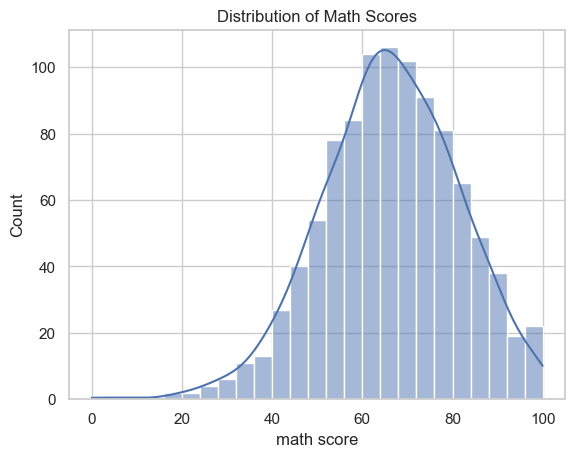

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: distribution of math scores
sns.histplot(df['math score'], kde=True)
plt.title("Distribution of Math Scores")
plt.show()


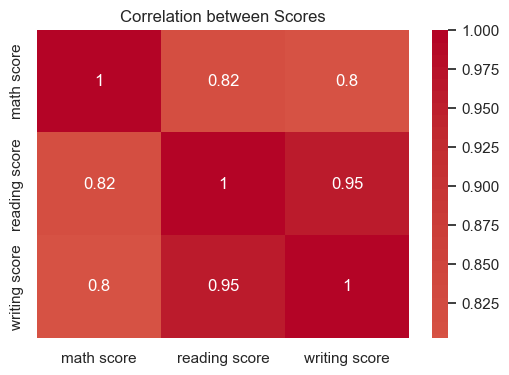

In [17]:
#Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[['math score','reading score','writing score']].corr(), 
            annot=True, cmap='coolwarm', center=0)
plt.title("Correlation between Scores")
plt.show()

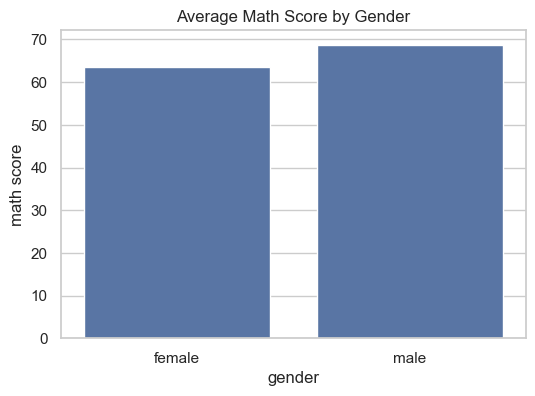

In [19]:
#Average Score by Gender
plt.figure(figsize=(6,4))
sns.barplot(x='gender', y='math score', data=df, errorbar=None)
plt.title("Average Math Score by Gender")
plt.show()

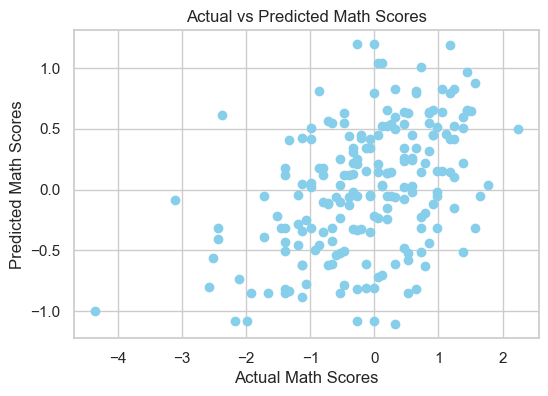

In [20]:
#Actual vs Predicted (Math Scores)
plt.figure(figsize=(6,4))
plt.scatter(y_test['math score'], y_pred[:,0], color='skyblue')
plt.xlabel("Actual Math Scores")
plt.ylabel("Predicted Math Scores")
plt.title("Actual vs Predicted Math Scores")
plt.show()